# Exit Strategies for Risk Management
**Docker image**: `ml4t`

## Purpose
Compare exit strategies that protect profits and limit losses on real ETF data:
fixed stops, trailing stops, ATR-scaled volatility exits, an ML exit signal, and
hybrid combinations. We measure stop-out frequency, win rate, and the trade-off
between loss control and avoidable churn.

## Learning Objectives
After completing this notebook, you will be able to:
- Implement fixed and trailing stop-loss rules
- Design ATR-scaled volatility-adjusted exits
- Calibrate stops to a strategy's realized MAE/MFE excursion profile
- Compare rule-based, ML-driven, and hybrid exit policies on the same trades

## Book reference
- Section 19.4 - Drawdowns, Path Risk, and Time-to-Recovery
- Section 19.7 - Adaptive Risk Controls Without Leakage

## Prerequisites
- Familiarity with OHLCV bars, ATR, and simple classification metrics
- Comfort interpreting stop-loss tradeoffs in terms of win rate and whipsaw risk

**Companion**: For the ML two-model entry/exit architecture, see
[`08_ml_exit_signals`](08_ml_exit_signals.ipynb).

## Setup

In [1]:
"""Compare fixed, trailing, and volatility-adjusted exit rules."""

import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from IPython.display import Markdown, display
from ml4t.backtest import risk
from ml4t.backtest.analytics import MAEMFEAnalyzer
from ml4t.backtest.types import Trade
from ml4t.diagnostic.config import (
    BarrierAnalysisSettings,
    BarrierColumnSettings,
    BarrierConfig,
)
from ml4t.diagnostic.evaluation import BarrierAnalysis
from plotly.subplots import make_subplots
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

from data import load_etfs
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
warnings.filterwarnings("ignore")

In [3]:
# Production defaults; Papermill injects overrides for CI
SEED = 42
LABEL_HORIZON = 5

In [4]:
np.random.seed(SEED)

## 1. Data Preparation

In [5]:
# Load sample data from canonical ETF source
SYMBOL = "SPY"
START_DATE = "2018-01-01"
END_DATE = "2024-01-01"

print(f"Loading {SYMBOL} data from canonical source...")
etf_data = load_etfs()

# Filter for SPY and date range
df = etf_data.filter(
    (pl.col("symbol") == SYMBOL)
    & (pl.col("timestamp") >= pl.lit(START_DATE).str.to_date())
    & (pl.col("timestamp") <= pl.lit(END_DATE).str.to_date())
).sort("timestamp")

print(f"Loaded {len(df):,} daily bars")

Loading SPY data from canonical source...
Loaded 1,509 daily bars


In [6]:
OUTPUT_DIR = get_output_dir(19, "exit_strategies")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [7]:
set_global_seeds(SEED)

In [8]:
# Add the base price and volatility features used by the exit rules.
df = df.with_columns(
    [
        (pl.col("close").pct_change()).alias("returns"),
        (pl.col("close").pct_change(5)).alias("returns_5d"),
        pl.max_horizontal(
            pl.col("high") - pl.col("low"),
            (pl.col("high") - pl.col("close").shift(1)).abs(),
            (pl.col("low") - pl.col("close").shift(1)).abs(),
        )
        .rolling_mean(14)
        .alias("atr_14"),
        pl.col("close").pct_change().rolling_std(20).alias("volatility_20"),
        pl.col("close").rolling_mean(20).alias("sma_20"),
        pl.col("close").rolling_mean(50).alias("sma_50"),
        pl.col("close").pct_change().alias("change"),
    ]
)

In [9]:
# Complete the RSI-style smoothing used in the ML exit model.
df = df.with_columns(
    [
        pl.when(pl.col("change") > 0).then(pl.col("change")).otherwise(0).alias("gain"),
        pl.when(pl.col("change") < 0).then(-pl.col("change")).otherwise(0).alias("loss"),
    ]
)

df = df.with_columns(
    [
        pl.col("gain").rolling_mean(14).alias("avg_gain"),
        pl.col("loss").rolling_mean(14).alias("avg_loss"),
    ]
)

df = df.with_columns(
    [
        (100 - 100 / (1 + pl.col("avg_gain") / pl.col("avg_loss"))).alias("rsi_14"),
    ]
)

df = df.drop_nulls()
print(f"After indicators: {len(df):,} bars")

After indicators: 1,460 bars


A single helper keeps the manual simulations consistent about how they record
trade-level exit information.

In [10]:
def build_exit_result(
    entry_idx: int,
    exit_idx: int,
    entry_price: float,
    exit_price: float,
    exit_type: str,
    extra: dict | None = None,
) -> dict:
    """Create a standard exit record for the simulation sections."""
    result = {
        "entry_idx": entry_idx,
        "exit_idx": exit_idx,
        "entry_price": entry_price,
        "exit_price": exit_price,
        "return": (exit_price / entry_price) - 1,
        "exit_type": exit_type,
        "holding_days": exit_idx - entry_idx,
    }
    if extra:
        result.update(extra)
    return result

A shared OHLC oracle makes gap handling and same-bar ordering explicit for
every fixed barrier simulation.

In [11]:
def long_barrier_fill(
    open_price: float,
    high_price: float,
    low_price: float,
    stop_price: float,
    take_profit_price: float,
) -> tuple[float, str] | None:
    """Return a gap-aware long-position barrier fill for one OHLC bar."""
    if open_price <= stop_price:
        return open_price, "stop_loss"
    if open_price >= take_profit_price:
        return open_price, "take_profit"

    stop_hit = low_price <= stop_price
    take_profit_hit = high_price >= take_profit_price
    if stop_hit:
        # Daily bars do not reveal whether the high or low occurred first.
        # Use the conservative stop-first convention when both are touched.
        return stop_price, "stop_loss"
    if take_profit_hit:
        return take_profit_price, "take_profit"
    return None

## 2. Fixed Take Profit / Stop Loss

The simplest exit strategy: exit when price hits a fixed percentage target or stop.

The fixed-stop configuration exposes the two policy parameters: the acceptable loss and the take-profit target.

In [12]:
@dataclass
class FixedExitConfig:
    """Configuration for fixed take profit / stop loss."""

    take_profit_pct: float = 0.05  # 5% take profit
    stop_loss_pct: float = 0.02  # 2% stop loss

The simulator treats the stop and target as resting orders from the entry close. Overnight gaps
fill at the next open; intraday touches fill at the barrier. When a daily bar touches both, the
conservative stop-first convention resolves the unknown ordering.

In [13]:
def simulate_fixed_exits(
    prices: np.ndarray,
    opens: np.ndarray,
    highs: np.ndarray,
    lows: np.ndarray,
    entry_indices: np.ndarray,
    config: FixedExitConfig,
    max_holding_days: int = 20,
) -> list[dict]:
    """Simulate fixed take-profit and stop-loss exits."""
    results = []

    for entry_idx in entry_indices:
        window_end = min(entry_idx + max_holding_days, len(prices) - 1)
        entry_price = prices[entry_idx]
        tp_price = entry_price * (1 + config.take_profit_pct)
        sl_price = entry_price * (1 - config.stop_loss_pct)
        exit_idx = window_end
        exit_price = prices[window_end]
        exit_type = "timeout"

        for i in range(entry_idx + 1, window_end + 1):
            fill = long_barrier_fill(opens[i], highs[i], lows[i], sl_price, tp_price)
            if fill is not None:
                exit_idx = i
                exit_price, exit_type = fill
                break

        results.append(build_exit_result(entry_idx, exit_idx, entry_price, exit_price, exit_type))

    return results

In [14]:
# Generate random entry signals (for demonstration)
# In practice, these would come from your alpha signal
n_trades = 100
entry_indices = np.sort(np.random.choice(range(50, len(df) - 50), size=n_trades, replace=False))

# Simulate with different stop loss levels
prices = df["close"].to_numpy()
opens = df["open"].to_numpy()
highs = df["high"].to_numpy()
lows = df["low"].to_numpy()
# Timestamp per bar (df coordinate). The ML section keys exit probabilities
# by timestamp because df_ml drops additional warm-up / forward-target rows
# and therefore does NOT share df's integer index.
# Normalize to a single unit so timestamp keys hash-match across the
# polars-native and pandas-converted datetime64 arrays (different units
# are ==-equal but not hash-equal).
bar_timestamps = df["timestamp"].to_numpy().astype("datetime64[ns]")

configs = [
    FixedExitConfig(take_profit_pct=0.05, stop_loss_pct=0.01),  # Tight stop
    FixedExitConfig(take_profit_pct=0.05, stop_loss_pct=0.02),  # Medium stop
    FixedExitConfig(take_profit_pct=0.05, stop_loss_pct=0.03),  # Wide stop
]

results_by_config = {}
for config in configs:
    results = simulate_fixed_exits(prices, opens, highs, lows, entry_indices, config)
    results_by_config[f"SL={config.stop_loss_pct:.0%}"] = results

The summary separates stop-outs, targets, and timeouts so the cost of tightening
the downside barrier is visible rather than inferred from mean return alone.

In [15]:
fixed_summary_rows = []
for name, results in results_by_config.items():
    returns = [r["return"] for r in results]
    exit_types = [r["exit_type"] for r in results]
    fixed_summary_rows.append(
        {
            "config": name,
            "mean_return_pct": np.mean(returns) * 100,
            "win_rate_pct": sum(1 for r in returns if r > 0) / len(returns) * 100,
            "take_profits": exit_types.count("take_profit"),
            "stop_losses": exit_types.count("stop_loss"),
            "timeouts": exit_types.count("timeout"),
        }
    )
fixed_summary_df = pl.DataFrame(fixed_summary_rows).with_columns(pl.exclude("config").round(2))
fixed_summary_df

config,mean_return_pct,win_rate_pct,take_profits,stop_losses,timeouts
str,f64,f64,i64,i64,i64
"""SL=1%""",0.33,29.0,16,71,13
"""SL=2%""",0.44,46.0,18,51,31
"""SL=3%""",0.11,48.0,18,49,33


In [16]:
# Persist trade-return distribution by stop-loss config for the figure-19.4 publication script.
fixed_returns_rows = []
for name, results in results_by_config.items():
    for r in results:
        fixed_returns_rows.append({"config": name, "return_pct": r["return"] * 100})
pl.DataFrame(fixed_returns_rows).write_parquet(OUTPUT_DIR / "fixed_stop_loss_returns.parquet")

All three panels use bins derived once from the pooled returns. Identical bin
edges and axis limits make differences in shape and tail mass comparable.

In [17]:
pooled_fixed_returns = np.concatenate(
    [
        np.asarray([result["return"] * 100 for result in results], dtype=float)
        for results in results_by_config.values()
    ]
)
pooled_range = float(np.ptp(pooled_fixed_returns))
histogram_padding = 0.02 * pooled_range
histogram_start = float(pooled_fixed_returns.min() - histogram_padding)
histogram_end = float(pooled_fixed_returns.max() + histogram_padding)
histogram_size = (histogram_end - histogram_start) / 30

fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=list(results_by_config.keys()),
    shared_xaxes=True,
    shared_yaxes=True,
)

The aligned panels now isolate distributional differences rather than changes
introduced by Plotly's panel-specific automatic binning.

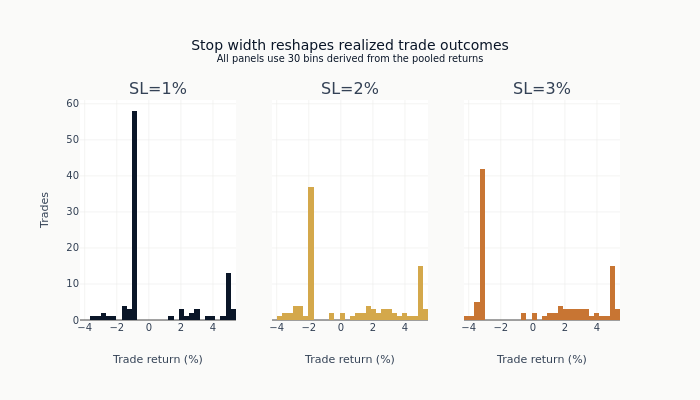

In [18]:
stop_colors = [COLORS["blue"], COLORS["amber"], COLORS["copper"]]
for i, ((name, results), color) in enumerate(
    zip(results_by_config.items(), stop_colors, strict=True), 1
):
    returns = [r["return"] * 100 for r in results]
    fig.add_trace(
        go.Histogram(
            x=returns,
            xbins={"start": histogram_start, "end": histogram_end, "size": histogram_size},
            name=name,
            marker_color=color,
        ),
        row=1,
        col=i,
    )
    fig.update_xaxes(
        title_text="Trade return (%)", range=[histogram_start, histogram_end], row=1, col=i
    )
    fig.update_yaxes(title_text="Trades" if i == 1 else None, row=1, col=i)

fig.update_layout(
    title={
        "text": "Stop width reshapes realized trade outcomes"
        "<br><sup>All panels use 30 bins derived from the pooled returns</sup>"
    },
    height=400,
    showlegend=False,
)
fig.show()

## 3. Trailing Stop Loss

Trailing stops follow price upward, locking in profits as the position moves favorably.

Trailing-stop settings separate the initial protection level from the distance that trails the high-water mark.

In [19]:
@dataclass
class TrailingStopConfig:
    """Configuration for trailing stop loss."""

    initial_stop_pct: float = 0.02  # Initial stop distance
    trail_pct: float = 0.015  # Trailing distance


def trailing_stop_fill(open_price: float, low_price: float, stop_price: float) -> float | None:
    """Return a gap-aware trailing-stop fill, if the resting stop is touched."""
    if open_price <= stop_price:
        return open_price
    if low_price <= stop_price:
        return stop_price
    return None

The trailing-stop simulator applies today's resting stop before using a new
high to tighten tomorrow's stop. This avoids assuming the unknown order of a
daily bar's high and low.

In [20]:
def simulate_trailing_stops(
    prices: np.ndarray,
    opens: np.ndarray,
    highs: np.ndarray,
    lows: np.ndarray,
    entry_indices: np.ndarray,
    config: TrailingStopConfig,
    max_holding_days: int = 50,
) -> list:
    """Simulate a trailing stop that ratchets upward with the high-water mark."""
    results = []

    for entry_idx in entry_indices:
        window_end = min(entry_idx + max_holding_days, len(prices) - 1)
        entry_price = prices[entry_idx]
        highest_since_entry = entry_price
        stop_price = entry_price * (1 - config.initial_stop_pct)
        exit_idx = window_end
        exit_price = prices[window_end]
        exit_type = "timeout"

        for i in range(entry_idx + 1, window_end + 1):
            fill = trailing_stop_fill(opens[i], lows[i], stop_price)
            if fill is not None:
                exit_idx = i
                exit_price = fill
                exit_type = "trailing_stop"
                break

            if highs[i] > highest_since_entry:
                highest_since_entry = highs[i]
                stop_price = max(stop_price, highest_since_entry * (1 - config.trail_pct))

        extra = {"highest_seen": highest_since_entry, "final_stop": stop_price}
        results.append(
            build_exit_result(entry_idx, exit_idx, entry_price, exit_price, exit_type, extra)
        )

    return results

In [21]:
trailing_configs = [
    TrailingStopConfig(initial_stop_pct=0.02, trail_pct=0.01),  # Tight trail
    TrailingStopConfig(initial_stop_pct=0.02, trail_pct=0.02),  # Medium trail
    TrailingStopConfig(initial_stop_pct=0.02, trail_pct=0.03),  # Wide trail
]

trailing_results = {}
for config in trailing_configs:
    results = simulate_trailing_stops(prices, opens, highs, lows, entry_indices, config)
    trailing_results[f"Trail={config.trail_pct:.0%}"] = results

# Compare to fixed stop
fixed_results = simulate_fixed_exits(
    prices,
    opens,
    highs,
    lows,
    entry_indices,
    FixedExitConfig(take_profit_pct=0.10, stop_loss_pct=0.02),
)

Trailing stops ratchet upward after favorable moves. The comparison shows how
tighter and wider trails exchange quicker protection for more room to recover.

In [22]:
trailing_rows = []
for name, results in trailing_results.items():
    returns = [r["return"] for r in results]
    trailing_rows.append(
        {
            "config": name,
            "mean_return_pct": np.mean(returns) * 100,
            "win_rate_pct": sum(1 for r in returns if r > 0) / len(returns) * 100,
            "avg_hold_days": float(np.mean([r["holding_days"] for r in results])),
        }
    )
trailing_rows.append(
    {
        "config": "Fixed SL/TP (baseline)",
        "mean_return_pct": np.mean([r["return"] for r in fixed_results]) * 100,
        "win_rate_pct": sum(1 for r in fixed_results if r["return"] > 0) / len(fixed_results) * 100,
        "avg_hold_days": float(np.mean([r["holding_days"] for r in fixed_results])),
    }
)
trailing_summary_df = pl.DataFrame(trailing_rows).with_columns(pl.exclude("config").round(2))
trailing_summary_df

config,mean_return_pct,win_rate_pct,avg_hold_days
str,f64,f64,f64
"""Trail=1%""",0.07,50.0,5.0
"""Trail=2%""",-0.23,35.0,9.35
"""Trail=3%""",0.29,38.0,16.66
"""Fixed SL/TP (baseline)""",0.39,45.0,12.4


## 4. Volatility-Adjusted Stops (ATR-Based)

ATR-based stops adapt to market volatility, using wider stops in volatile markets
and tighter stops in calm markets.

ATR configuration determines how many volatility units to allow on the downside and upside.

In [23]:
@dataclass
class ATRStopConfig:
    """Configuration for ATR-based stops."""

    atr_multiplier: float = 2.0  # Stop = entry - N * ATR
    take_profit_multiplier: float = 3.0  # TP = entry + N * ATR

ATR exits reuse the same barrier logic as fixed stops, but rescale both barriers by current volatility.

In [24]:
def simulate_atr_exits(
    prices: np.ndarray,
    opens: np.ndarray,
    highs: np.ndarray,
    lows: np.ndarray,
    atr: np.ndarray,
    entry_indices: np.ndarray,
    config: ATRStopConfig,
    max_holding_days: int = 30,
) -> list:
    """Simulate ATR-based exits with volatility-scaled barriers."""
    results = []

    for entry_idx in entry_indices:
        window_end = min(entry_idx + max_holding_days, len(prices) - 1)
        entry_price = prices[entry_idx]
        current_atr = atr[entry_idx]
        stop_price = entry_price - config.atr_multiplier * current_atr
        tp_price = entry_price + config.take_profit_multiplier * current_atr
        exit_idx = window_end
        exit_price = prices[window_end]
        exit_type = "timeout"

        for i in range(entry_idx + 1, window_end + 1):
            fill = long_barrier_fill(opens[i], highs[i], lows[i], stop_price, tp_price)
            if fill is not None:
                exit_idx = i
                exit_price, exit_type = fill
                break

        extra = {
            "atr_at_entry": current_atr,
            "stop_distance_pct": (entry_price - stop_price) / entry_price,
        }
        results.append(
            build_exit_result(entry_idx, exit_idx, entry_price, exit_price, exit_type, extra)
        )

    return results

In [25]:
# Simulate ATR-based exits
atr = df["atr_14"].to_numpy()

atr_configs = [
    ATRStopConfig(atr_multiplier=1.5, take_profit_multiplier=2.0),  # Tight
    ATRStopConfig(atr_multiplier=2.0, take_profit_multiplier=3.0),  # Medium
    ATRStopConfig(atr_multiplier=3.0, take_profit_multiplier=4.0),  # Wide
]

atr_results = {}
for config in atr_configs:
    results = simulate_atr_exits(prices, opens, highs, lows, atr, entry_indices, config)
    atr_results[f"ATR×{config.atr_multiplier}"] = results

ATR-scaled stops widen automatically when realized volatility is high and tighten
when it's calm; the standard deviation of stop distance shows how much the rule
adapts within a single configuration.

In [26]:
atr_rows = []
for name, results in atr_results.items():
    returns = [r["return"] for r in results]
    stop_distances = [r["stop_distance_pct"] * 100 for r in results]
    atr_rows.append(
        {
            "config": name,
            "mean_return_pct": np.mean(returns) * 100,
            "win_rate_pct": sum(1 for r in returns if r > 0) / len(returns) * 100,
            "avg_stop_distance_pct": float(np.mean(stop_distances)),
            "stop_distance_std_pct": float(np.std(stop_distances)),
        }
    )
atr_summary_df = pl.DataFrame(atr_rows).with_columns(pl.exclude("config").round(2))
atr_summary_df

config,mean_return_pct,win_rate_pct,avg_stop_distance_pct,stop_distance_std_pct
str,f64,f64,f64,f64
"""ATR×1.5""",0.12,48.0,1.94,0.82
"""ATR×2.0""",0.39,46.0,2.58,1.1
"""ATR×3.0""",0.65,53.0,3.88,1.65


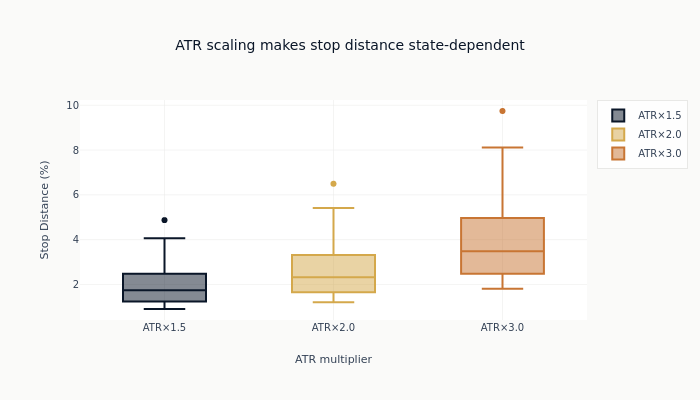

In [27]:
# Visualize how stop distance varies with volatility
fig = go.Figure()

for (name, results), color in zip(atr_results.items(), stop_colors, strict=True):
    stop_distances = [r["stop_distance_pct"] * 100 for r in results]
    fig.add_trace(go.Box(y=stop_distances, name=name, marker_color=color, line_color=color))

fig.update_layout(
    title="ATR scaling makes stop distance state-dependent",
    xaxis_title="ATR multiplier",
    yaxis_title="Stop Distance (%)",
    height=400,
)
fig.show()

## 5. ML-Based Exit Signals

Train a classifier to predict adverse price moves and use predictions for exits.

**Approach**:
- Target: Will price drop >2% in next 5 days?
- Features: Technical indicators, recent returns, volatility
- Model: Gradient Boosting
- Exit: Use today's close-based probability at the next session's open

In [28]:
# Prepare ML features and target
df_ml = df.with_columns(
    [
        # Target: price drops >2% in next 5 days
        (pl.col("close").shift(-LABEL_HORIZON) / pl.col("close") - 1 < -0.02)
        .cast(pl.Int32)
        .alias("target"),
        # Features
        pl.col("returns").alias("ret_1d"),
        pl.col("returns_5d").alias("ret_5d"),
        (pl.col("close").pct_change(10)).alias("ret_10d"),
        (pl.col("close").pct_change(20)).alias("ret_20d"),
        pl.col("volatility_20").alias("vol_20d"),
        pl.col("rsi_14").alias("rsi"),
        ((pl.col("close") - pl.col("sma_20")) / pl.col("sma_20")).alias("dist_sma20"),
        ((pl.col("close") - pl.col("sma_50")) / pl.col("sma_50")).alias("dist_sma50"),
        (pl.col("volume") / pl.col("volume").rolling_mean(20)).alias("vol_ratio"),
    ]
).drop_nulls()

In [29]:
# This notebook deliberately uses a self-contained exit model. The companion
# 08_ml_exit_signals notebook covers a two-model entry/exit architecture.
FEATURES = [
    "ret_1d",
    "ret_5d",
    "ret_10d",
    "ret_20d",
    "vol_20d",
    "rsi",
    "dist_sma20",
    "dist_sma50",
    "vol_ratio",
]

print(f"ML dataset: {len(df_ml):,} samples")
print(f"Target rate: {df_ml['target'].mean() * 100:.1f}% (adverse moves)")

ML dataset: 1,435 samples
Target rate: 15.0% (adverse moves)


In [30]:
# Train/test split. Five rows are purged before the test boundary because each
# training label reads five closes forward. This keeps every training outcome
# strictly before the first test feature row.
df_pd = df_ml.to_pandas()
test_start = int(len(df_pd) * 0.7)
train_end = test_start - LABEL_HORIZON

X_train = df_pd[FEATURES].iloc[:train_end]
y_train = df_pd["target"].iloc[:train_end]
X_test = df_pd[FEATURES].iloc[test_start:]
y_test = df_pd["target"].iloc[test_start:]
test_timestamps = df_pd["timestamp"].iloc[test_start:].to_numpy().astype("datetime64[ns]")

print(f"Train: {len(X_train):,} samples, Purged: {LABEL_HORIZON}, Test: {len(X_test):,} samples")

Train: 999 samples, Purged: 5, Test: 431 samples


In [31]:
# Train model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=SEED,
)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)
test_auc = roc_auc_score(y_test, y_pred_proba)

# Evaluation
print("\nModel Performance (Test Set):")
print(f"AUC-ROC: {test_auc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Hold", "Exit Signal"]))


Model Performance (Test Set):
AUC-ROC: 0.547

Classification Report:
              precision    recall  f1-score   support

        Hold       0.81      0.95      0.88       350
 Exit Signal       0.24      0.06      0.10        81

    accuracy                           0.79       431
   macro avg       0.53      0.51      0.49       431
weighted avg       0.71      0.79      0.73       431



Mean decrease in impurity is recomputed on expanding chronological training
folds. The test period remains untouched, and fold dispersion shows how stable
each feature's attribution is across training vintages.

In [32]:
importance_rows = []
importance_splitter = TimeSeriesSplit(n_splits=5, gap=LABEL_HORIZON)
for fold, (fold_fit_idx, _) in enumerate(importance_splitter.split(X_train), start=1):
    fold_scaler = StandardScaler()
    X_fold_scaled = fold_scaler.fit_transform(X_train.iloc[fold_fit_idx])
    fold_model = GradientBoostingClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=SEED,
    )
    fold_model.fit(X_fold_scaled, y_train.iloc[fold_fit_idx])
    importance_rows.extend(
        {
            "fold": fold,
            "feature": feature,
            "importance": float(importance),
        }
        for feature, importance in zip(FEATURES, fold_model.feature_importances_, strict=True)
    )

importance_summary = (
    pl.DataFrame(importance_rows)
    .group_by("feature")
    .agg(
        pl.col("importance").mean().alias("mean_importance"),
        pl.col("importance").std().alias("std_importance"),
    )
    .sort("mean_importance")
)

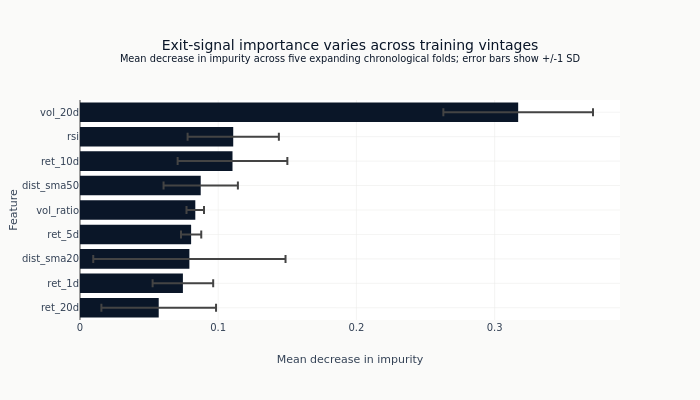

In [33]:
fig = go.Figure(
    go.Bar(
        x=importance_summary["mean_importance"].to_list(),
        y=importance_summary["feature"].to_list(),
        orientation="h",
        error_x={
            "type": "data",
            "array": importance_summary["std_importance"].to_list(),
            "visible": True,
        },
        marker_color=COLORS["blue"],
    )
)
fig.update_layout(
    title={
        "text": "Exit-signal importance varies across training vintages"
        "<br><sup>Mean decrease in impurity across five expanding chronological folds; "
        "error bars show +/-1 SD</sup>"
    },
    xaxis_title="Mean decrease in impurity",
    yaxis_title="Feature",
    height=400,
)
fig.show()

The exit probabilities are keyed by timestamp, not by row position. The
mapping delays each close-based probability until the next session's open.
Bars without an out-of-sample execution signal never trigger an ML exit.

In [34]:
def ml_exit_triggered(
    proba_by_ts: dict,
    idx: int,
    exit_threshold: float,
    bar_timestamps: np.ndarray,
) -> bool:
    """Return True when the bar has a prior-close exit signal above the threshold."""
    proba = proba_by_ts.get(bar_timestamps[idx])
    return proba is not None and proba > exit_threshold

The ML exit simulator treats a high adverse-move probability as an early exit signal.

In [35]:
def simulate_ml_exits(
    prices: np.ndarray,
    opens: np.ndarray,
    proba_by_ts: dict,
    entry_indices: np.ndarray,
    bar_timestamps: np.ndarray,
    exit_threshold: float = 0.5,
    max_holding_days: int = 30,
) -> list:
    """
    Simulate exits based on ML predictions.

    Exit at the next session's open when the prior close's adverse-move
    probability exceeds the threshold. Only entries in the test period are
    simulated.
    """
    results = []

    for entry_idx in entry_indices:
        window_end = min(entry_idx + max_holding_days, len(prices) - 1)
        entry_price = prices[entry_idx]
        exit_idx = window_end
        exit_type = "timeout"

        for i in range(entry_idx + 1, window_end + 1):
            if ml_exit_triggered(proba_by_ts, i, exit_threshold, bar_timestamps):
                exit_idx = i
                exit_price = opens[i]
                exit_type = "ml_signal"
                break
        else:
            exit_price = prices[exit_idx]

        results.append(build_exit_result(entry_idx, exit_idx, entry_price, exit_price, exit_type))

    return results

In [36]:
# Map each test close's probability to the next session, when it can first be
# executed. The timestamp lookup avoids assuming df and df_ml share row indices.
bar_index_by_timestamp = {timestamp: i for i, timestamp in enumerate(bar_timestamps)}
proba_by_ts = {}
for signal_timestamp, probability in zip(test_timestamps, y_pred_proba, strict=True):
    signal_idx = bar_index_by_timestamp[signal_timestamp]
    if signal_idx + 1 < len(bar_timestamps):
        proba_by_ts[bar_timestamps[signal_idx + 1]] = probability

test_cutoff_ts = min(proba_by_ts)
test_entries = entry_indices[bar_timestamps[entry_indices] >= test_cutoff_ts]

ml_results = {}
for threshold in [0.3, 0.5, 0.7]:
    results = simulate_ml_exits(
        prices, opens, proba_by_ts, test_entries, bar_timestamps, exit_threshold=threshold
    )
    if results:
        ml_results[f"ML (p>{threshold})"] = results

# Baseline: no ML exit (just timeout)
baseline_results = simulate_ml_exits(
    prices,
    opens,
    {},  # Empty map means no bar ever triggers an ML exit
    test_entries,
    bar_timestamps,
    exit_threshold=2.0,  # Never triggers
)

if baseline_results:
    ml_results["No Exit Signal"] = baseline_results

At each probability threshold the ML rule fires more often when the threshold is low
and falls back to time-exit when the threshold is high. The threshold is the lever
that trades off coverage against signal quality.

In [37]:
ml_rows = []
for name, results in ml_results.items():
    returns = [r["return"] for r in results]
    exit_types = [r["exit_type"] for r in results]
    ml_rows.append(
        {
            "config": name,
            "n_trades": len(results),
            "mean_return_pct": np.mean(returns) * 100,
            "win_rate_pct": sum(1 for r in returns if r > 0) / len(returns) * 100,
            "ml_exits": exit_types.count("ml_signal"),
            "timeouts": exit_types.count("timeout"),
        }
    )
ml_summary_df = pl.DataFrame(ml_rows).with_columns(pl.exclude("config").round(2))
ml_summary_df

config,n_trades,mean_return_pct,win_rate_pct,ml_exits,timeouts
str,i64,f64,f64,i64,i64
"""ML (p>0.3)""",28,-0.54,39.29,17,11
"""ML (p>0.5)""",28,0.12,42.86,13,15
"""ML (p>0.7)""",28,0.18,46.43,7,21
"""No Exit Signal""",28,-0.01,50.0,0,28


In [38]:
display(
    Markdown(
        f"The chronological test AUC is {test_auc:.3f}. Lower thresholds fire on more bars, "
        "while higher thresholds defer more trades to the time exit. These threshold results "
        "are a descriptive sensitivity analysis on one test interval, not a second round of "
        "model selection."
    )
)

The chronological test AUC is 0.547. Lower thresholds fire on more bars, while higher thresholds defer more trades to the time exit. These threshold results are a descriptive sensitivity analysis on one test interval, not a second round of model selection.

## 6. Combining Exit Strategies

In practice, combine multiple exit signals:
- Stop loss for downside protection
- Take profit for upside capture
- Trailing stop to lock in gains
- ML signal for regime detection

The hybrid policy exposes which mix of fixed, trailing, and ML exits drives the final path.

In [39]:
@dataclass
class HybridExitConfig:
    """Combined exit strategy configuration."""

    # Fixed stops
    initial_stop_pct: float = 0.02
    take_profit_pct: float = 0.06

    # Trailing
    enable_trailing: bool = True
    trail_pct: float = 0.015

    # ML
    enable_ml: bool = True
    ml_threshold: float = 0.5

The simulator evaluates the barriers in priority order so we can attribute each exit to a specific trigger.

In [40]:
def hybrid_bar_fill(
    open_price: float,
    high_price: float,
    low_price: float,
    stop_price: float,
    take_profit_price: float,
    ml_exit: bool,
    stop_type: str,
) -> tuple[float, str] | None:
    """Return the first executable hybrid exit under the documented priority."""
    if open_price <= stop_price:
        return open_price, stop_type
    if open_price >= take_profit_price:
        return open_price, "take_profit"
    if ml_exit:
        return open_price, "ml_signal"
    if low_price <= stop_price:
        return stop_price, stop_type
    if high_price >= take_profit_price:
        return take_profit_price, "take_profit"
    return None

A single-trade helper owns the event ordering. Keeping it separate makes the
portfolio-level simulator a transparent application over entry timestamps.

In [41]:
def simulate_one_hybrid_exit(
    prices: np.ndarray,
    opens: np.ndarray,
    highs: np.ndarray,
    lows: np.ndarray,
    proba_by_ts: dict | None,
    entry_idx: int,
    config: HybridExitConfig,
    bar_timestamps: np.ndarray,
    max_holding_days: int,
) -> dict:
    """Simulate one trade under the hybrid event-ordering contract."""
    window_end = min(entry_idx + max_holding_days, len(prices) - 1)
    entry_price = prices[entry_idx]
    highest_since_entry = entry_price
    initial_stop_price = entry_price * (1 - config.initial_stop_pct)
    stop_price = initial_stop_price
    tp_price = entry_price * (1 + config.take_profit_pct)
    exit_idx, exit_price, exit_type = window_end, prices[window_end], "timeout"

    for i in range(entry_idx + 1, window_end + 1):
        ml_exit = (
            config.enable_ml
            and proba_by_ts is not None
            and ml_exit_triggered(proba_by_ts, i, config.ml_threshold, bar_timestamps)
        )
        is_trailing = config.enable_trailing and stop_price > initial_stop_price
        stop_type = "trailing_stop" if is_trailing else "stop_loss"
        fill = hybrid_bar_fill(
            opens[i], highs[i], lows[i], stop_price, tp_price, ml_exit, stop_type
        )
        if fill is not None:
            exit_idx, (exit_price, exit_type) = i, fill
            break
        if config.enable_trailing and highs[i] > highest_since_entry:
            highest_since_entry = highs[i]
            stop_price = max(stop_price, highest_since_entry * (1 - config.trail_pct))

    return build_exit_result(entry_idx, exit_idx, entry_price, exit_price, exit_type)

The outer simulator applies the single-trade contract to each entry without
adding any alternative timing or fill behavior.

In [42]:
def simulate_hybrid_exits(
    prices: np.ndarray,
    opens: np.ndarray,
    highs: np.ndarray,
    lows: np.ndarray,
    proba_by_ts: dict | None,
    entry_indices: np.ndarray,
    config: HybridExitConfig,
    bar_timestamps: np.ndarray,
    max_holding_days: int = 30,
) -> list:
    """Simulate hybrid exit strategy combining multiple signals."""
    results = []
    for entry_idx in entry_indices:
        result = simulate_one_hybrid_exit(
            prices,
            opens,
            highs,
            lows,
            proba_by_ts,
            entry_idx,
            config,
            bar_timestamps,
            max_holding_days,
        )
        results.append(result)

    return results

In [43]:
# Compare hybrid strategies
hybrid_configs = {
    "Fixed Only": HybridExitConfig(enable_trailing=False, enable_ml=False),
    "Fixed + Trailing": HybridExitConfig(enable_trailing=True, enable_ml=False),
    "Fixed + ML": HybridExitConfig(enable_trailing=False, enable_ml=True),
    "Full Hybrid": HybridExitConfig(enable_trailing=True, enable_ml=True),
}

hybrid_results = {}
for name, config in hybrid_configs.items():
    results = simulate_hybrid_exits(
        prices,
        opens,
        highs,
        lows,
        proba_by_ts,
        test_entries,
        config=config,
        bar_timestamps=bar_timestamps,
    )
    if results:
        hybrid_results[name] = results

In [44]:
comparison_data = []
for name, results in hybrid_results.items():
    returns = [r["return"] for r in results]
    exit_types = [r["exit_type"] for r in results]

    comparison_data.append(
        {
            "Strategy": name,
            "Mean Return": f"{np.mean(returns) * 100:+.2f}%",
            "Trade Return / SD": f"{np.mean(returns) / np.std(returns):.2f}",
            "Win Rate": f"{sum(1 for r in returns if r > 0) / len(returns) * 100:.1f}%",
            "Stop Losses": exit_types.count("stop_loss"),
            "Trailing Stops": exit_types.count("trailing_stop"),
            "Take Profits": exit_types.count("take_profit"),
            "ML Exits": exit_types.count("ml_signal"),
        }
    )

comparison_df = pl.DataFrame(comparison_data)
comparison_df

Strategy,Mean Return,Trade Return / SD,Win Rate,Stop Losses,Trailing Stops,Take Profits,ML Exits
str,str,str,str,i64,i64,i64,i64
"""Fixed Only""","""-0.12%""","""-0.04""","""32.1%""",18,0,5,0
"""Fixed + Trailing""","""-0.24%""","""-0.15""","""39.3%""",6,22,0,0
"""Fixed + ML""","""+0.16%""","""0.05""","""35.7%""",15,0,5,3
"""Full Hybrid""","""-0.24%""","""-0.15""","""39.3%""",6,21,0,1


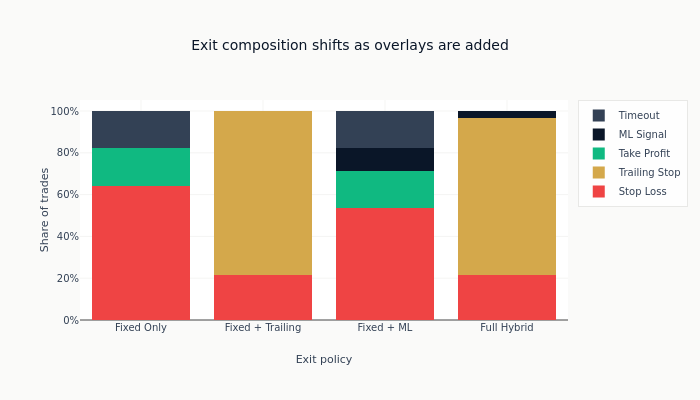

In [45]:
# Exit type breakdown as comparable shares across strategies.
exit_type_colors = {
    "stop_loss": COLORS["negative"],
    "trailing_stop": COLORS["amber"],
    "take_profit": COLORS["positive"],
    "ml_signal": COLORS["blue"],
    "timeout": COLORS["neutral"],
}
exit_labels = {
    "stop_loss": "Stop Loss",
    "trailing_stop": "Trailing Stop",
    "take_profit": "Take Profit",
    "ml_signal": "ML Signal",
    "timeout": "Timeout",
}
exit_order = ["stop_loss", "trailing_stop", "take_profit", "ml_signal", "timeout"]
fig = go.Figure()
for exit_type in exit_order:
    shares = []
    for results in hybrid_results.values():
        exit_types = [result["exit_type"] for result in results]
        shares.append(exit_types.count(exit_type) / len(exit_types))
    fig.add_trace(
        go.Bar(
            x=list(hybrid_results),
            y=shares,
            name=exit_labels[exit_type],
            marker_color=exit_type_colors[exit_type],
        ),
    )

fig.update_layout(
    title="Exit composition shifts as overlays are added",
    xaxis_title="Exit policy",
    yaxis_title="Share of trades",
    yaxis_tickformat=".0%",
    barmode="stack",
    height=400,
)
fig.show()

## 7. ml4t-backtest Risk Rules

The manual simulations above teach how exit rules work internally. For production,
use **ml4t.backtest.risk** - a composable library of position-level exit rules.

**Key Concepts:**
- **PositionRule**: Base class for rules that act on individual positions
- **RuleChain**: Compose multiple rules (evaluated in order)
- **AllOf/AnyOf**: Logical AND/OR composition of rules

**Available Rules:**
| Rule | Description |
|------|-------------|
| `StopLoss` | Exit when position loses N% |
| `TakeProfit` | Exit when position gains N% |
| `TrailingStop` | Trail price with fixed percentage |
| `TighteningTrailingStop` | Trail tightens as profit grows |
| `VolatilityStop` | ATR-based stop loss |
| `VolatilityTrailingStop` | ATR-based trailing stop |
| `TimeExit` | Exit after N bars |
| `SignalExit` | Exit on external signal |

In [46]:
# Example 1: Basic StopLoss / TakeProfit composition
#
# RuleChain evaluates rules in order, first to trigger wins

basic_exit = risk.RuleChain(
    rules=[
        risk.StopLoss(pct=0.02),  # 2% stop loss
        risk.TakeProfit(pct=0.05),  # 5% take profit
        risk.TimeExit(max_bars=20),  # Exit after 20 bars if neither triggered
    ]
)

print("Basic Exit RuleChain:")
print(f"  Rules: {[type(r).__name__ for r in basic_exit.rules]}")

Basic Exit RuleChain:
  Rules: ['StopLoss', 'TakeProfit', 'TimeExit']


In [47]:
# Example 2: Trailing stop with take profit
#
# Trailing stop locks in profits as position moves favorably

trailing_exit = risk.RuleChain(
    rules=[
        risk.StopLoss(pct=0.03),  # Initial 3% stop (safety net)
        risk.TrailingStop(pct=0.015),  # Trail 1.5% below peak
        risk.TakeProfit(pct=0.10),  # Take 10% profit
        risk.TimeExit(max_bars=50),  # Max 50 bar hold
    ]
)

print("\nTrailing Exit RuleChain:")
print(f"  Rules: {[type(r).__name__ for r in trailing_exit.rules]}")


Trailing Exit RuleChain:
  Rules: ['StopLoss', 'TrailingStop', 'TakeProfit', 'TimeExit']


In [48]:
# Example 3: AllOf / AnyOf composition
#
# AnyOf: Exit if ANY condition is true (OR logic)
# AllOf: Exit if ALL conditions are true (AND logic)

# AnyOf example: Exit if stop OR profit target hit
any_of_exit = risk.AnyOf(
    rules=[
        risk.StopLoss(pct=0.02),
        risk.TakeProfit(pct=0.05),
    ]
)

# AllOf example: Exit only if BOTH time exceeded AND trailing triggered
# (Useful for: "after 10 bars, start trailing")
all_of_exit = risk.AllOf(
    rules=[
        risk.TimeExit(max_bars=10),  # Must be past 10 bars
        risk.TrailingStop(pct=0.02),  # AND trailing triggered
    ]
)

print("\nComposition Patterns:")
print(f"  AnyOf (OR): {[type(r).__name__ for r in any_of_exit.rules]}")
print(f"  AllOf (AND): {[type(r).__name__ for r in all_of_exit.rules]}")


Composition Patterns:
  AnyOf (OR): ['StopLoss', 'TakeProfit']
  AllOf (AND): ['TimeExit', 'TrailingStop']


In [49]:
# Example 4: Volatility-adjusted exit rules
#
# VolatilityStop uses ATR for adaptive stop levels

vol_exit = risk.RuleChain(
    rules=[
        risk.VolatilityStop(multiplier=2.0),  # Stop = entry - 2*ATR
        risk.TakeProfit(pct=0.08),  # 8% take profit
        risk.TimeExit(max_bars=30),
    ]
)

print("\nVolatility-Adjusted Exit:")
print(f"  Rules: {[type(r).__name__ for r in vol_exit.rules]}")


Volatility-Adjusted Exit:
  Rules: ['VolatilityStop', 'TakeProfit', 'TimeExit']


In [50]:
# Example 5: TighteningTrailingStop - trail tightens as profit grows
#
# This rule uses a schedule: list of (return_threshold, trail_pct) tuples.
# The trail percentage decreases at higher profit levels, locking in more gains.

tightening_exit = risk.RuleChain(
    rules=[
        risk.StopLoss(pct=0.03),  # 3% initial stop
        risk.TighteningTrailingStop(
            schedule=[
                (0.00, 0.03),  # At 0% profit: 3% trail
                (0.05, 0.02),  # At 5%+ profit: 2% trail
                (0.10, 0.01),  # At 10%+ profit: 1% trail
            ]
        ),
        risk.TakeProfit(pct=0.15),  # 15% take profit
    ]
)

print("\nTightening Trailing Stop:")
print(f"  Rules: {[type(r).__name__ for r in tightening_exit.rules]}")


Tightening Trailing Stop:
  Rules: ['StopLoss', 'TighteningTrailingStop', 'TakeProfit']


### Evaluating Rules with PositionState

The examples above show rule *creation*. Now let's *evaluate* them against
concrete position states. All rules accept a `PositionState` and return a
`PositionAction` with `action`, `stop_price`, and `reason` fields.
Context data (ATR, signals) is passed via `PositionState.context`.

This helper fabricates a minimal `PositionState` so we can test one rule at a time without a full engine run.

In [51]:
def create_position_state(
    entry_price: float = 100.0,
    current_price: float = 102.0,
    quantity: int = 100,
    high_water_mark: float | None = None,
    bars_held: int = 10,
    context: dict | None = None,
) -> risk.PositionState:
    """Create a PositionState for rule evaluation."""
    hwm = high_water_mark or max(entry_price, current_price)
    lwm = min(entry_price, current_price)
    return risk.PositionState(
        asset="TEST",
        side="long",
        entry_price=entry_price,
        current_price=current_price,
        quantity=quantity,
        initial_quantity=quantity,
        unrealized_pnl=(current_price - entry_price) * quantity,
        unrealized_return=(current_price - entry_price) / entry_price,
        bars_held=bars_held,
        high_water_mark=hwm,
        low_water_mark=lwm,
        bar_open=current_price - 0.5,
        bar_high=current_price + 1.0,
        bar_low=current_price - 1.0,
        context=context or {},
    )

A tiny predicate keeps the rule-evaluation examples readable.

In [52]:
def should_exit(result) -> bool:
    """Check if result indicates an exit action."""
    return result.action != risk.ActionType.HOLD

`VolatilityStop` widens its fixed stop as ATR rises. The same current price can
therefore trigger an exit in a calm regime but remain inside the risk budget in
a volatile regime.

In [53]:
# Use current-ATR mode so each independent scenario evaluates its displayed ATR.
# Production code can instead keep entry ATR in one rule instance per position.
stop_2x = risk.VolatilityStop(multiplier=2.0, atr_key="atr", use_entry_atr=False)

scenarios = [
    ("Low volatility (ATR=1.0)", 1.0, 98.0),
    ("Normal volatility (ATR=2.0)", 2.0, 98.0),
    ("High volatility (ATR=4.0)", 4.0, 98.0),
]
volatility_stop_rows = []
for name, atr_val, current_price in scenarios:
    state = create_position_state(
        entry_price=100.0, current_price=current_price, context={"atr": atr_val}
    )
    result = stop_2x.evaluate(state)
    stop_level = 100.0 - (atr_val * 2.0)
    volatility_stop_rows.append(
        {
            "Scenario": name,
            "ATR": atr_val,
            "Stop Level ($)": stop_level,
            "Current ($)": current_price,
            "Decision": "Exit" if should_exit(result) else "Hold",
        }
    )
pl.DataFrame(volatility_stop_rows)

Scenario,ATR,Stop Level ($),Current ($),Decision
str,f64,f64,f64,str
"""Low volatility (ATR=1.0)""",1.0,98.0,98.0,"""Exit"""
"""Normal volatility (ATR=2.0)""",2.0,96.0,98.0,"""Hold"""
"""High volatility (ATR=4.0)""",4.0,92.0,98.0,"""Hold"""


`VolatilityTrailingStop` follows the high-water mark while preserving an
ATR-scaled cushion. The path display makes the ratchet and eventual exit visible.

In [54]:
trail_rule = risk.VolatilityTrailingStop(multiplier=2.0, atr_key="atr")
entry_price = 100.0
sim_prices = [100, 102, 104, 106, 105, 103, 101, 99]
atr_val = 2.0
hwm = entry_price
trailing_stop_rows = []
for i, price in enumerate(sim_prices):
    hwm = max(hwm, price)
    trail_stop = hwm - (atr_val * 2)
    state = create_position_state(
        entry_price=entry_price,
        current_price=price,
        high_water_mark=hwm,
        context={"atr": atr_val},
    )
    result = trail_rule.evaluate(state)
    trailing_stop_rows.append(
        {
            "Bar": i,
            "Price ($)": price,
            "High-Water Mark ($)": hwm,
            "Trail Stop ($)": trail_stop,
            "Decision": "Exit" if should_exit(result) else "Hold",
        }
    )
pl.DataFrame(trailing_stop_rows)

Bar,Price ($),High-Water Mark ($),Trail Stop ($),Decision
i64,i64,f64,f64,str
0,100,100.0,96.0,"""Hold"""
1,102,102.0,98.0,"""Hold"""
2,104,104.0,100.0,"""Hold"""
3,106,106.0,102.0,"""Hold"""
4,105,106.0,102.0,"""Hold"""
5,103,106.0,102.0,"""Hold"""
6,101,106.0,102.0,"""Exit"""
7,99,106.0,102.0,"""Exit"""


`SignalExit` maps the signed model signal to a discrete exit decision. Values
below the negative threshold trigger an exit for the long position.

In [55]:
signal_rule = risk.SignalExit(signal_name="exit_signal", threshold=0.3)
signal_exit_rows = []
for signal_value in [0.5, 0.0, -0.2, -0.4, -0.8]:
    state = create_position_state(context={"exit_signal": signal_value})
    result = signal_rule.evaluate(state)
    signal_exit_rows.append(
        {
            "Signal": signal_value,
            "Decision": "Exit" if should_exit(result) else "Hold",
            "Reason": result.reason if should_exit(result) else None,
        }
    )
pl.DataFrame(signal_exit_rows)

Signal,Decision,Reason
f64,str,str
0.5,"""Hold""",null
0.0,"""Hold""",null
-0.2,"""Hold""",null
-0.4,"""Exit""","""signal_exit_-0.40"""
-0.8,"""Exit""","""signal_exit_-0.80"""


### MAE/MFE-Calibrated Exit Rules

Use the realized SPY paths from the representative ATR x2.0 trades to set
data-driven stop and target levels. The `MAEMFEAnalyzer` from
ml4t-backtest computes thresholds from the resulting `Trade` objects.

In [56]:
trades_list = []
trades_data = []
for result in atr_results["ATR×2.0"]:
    entry_idx = result["entry_idx"]
    exit_idx = result["exit_idx"]
    entry_price = result["entry_price"]
    exit_price = result["exit_price"]
    # A barrier exit can occur before the exit bar's later high or low. Include
    # full OHLC only through the preceding bar, then add the observed fill.
    full_bar_end = exit_idx + 1 if result["exit_type"] == "timeout" else exit_idx
    path_lows = lows[entry_idx + 1 : full_bar_end]
    path_highs = highs[entry_idx + 1 : full_bar_end]
    adverse_prices = np.append(path_lows, exit_price)
    favorable_prices = np.append(path_highs, exit_price)
    mae = min(float(adverse_prices.min() / entry_price - 1), 0.0)
    mfe = max(float(favorable_prices.max() / entry_price - 1), 0.0)
    trade = Trade(
        symbol=SYMBOL,
        entry_time=pd.Timestamp(bar_timestamps[entry_idx]).to_pydatetime(),
        exit_time=pd.Timestamp(bar_timestamps[exit_idx]).to_pydatetime(),
        entry_price=entry_price,
        exit_price=exit_price,
        quantity=1,
        pnl=exit_price - entry_price,
        pnl_percent=result["return"],
        bars_held=result["holding_days"],
        mfe=mfe,
        mae=mae,
    )
    trades_list.append(trade)
    trades_data.append({"pnl_pct": result["return"], "mae": abs(mae), "mfe": mfe})

mae_df = pl.DataFrame(trades_data)
print(f"Trades: {len(mae_df)}, Win rate: {(mae_df['pnl_pct'] > 0).mean():.1%}")

Trades: 100, Win rate: 46.0%


In [57]:
# Compute optimal exit levels
analyzer = MAEMFEAnalyzer(trades_list)
levels = analyzer.optimal_exit_levels(stop_percentile=90, target_percentile=75)
stop_val = levels["stop_loss"]
target_val = levels["take_profit"]

print(f"Edge Ratio: {analyzer.edge_ratio:.2f}")
print(f"90th percentile |MAE| (stop): {abs(stop_val):.2%}")
print(f"75th percentile MFE (target): {target_val:.2%}")

# Assemble calibrated exit strategy
calibrated_exit = risk.RuleChain(
    rules=[
        risk.StopLoss(pct=abs(stop_val)),
        risk.TakeProfit(pct=target_val),
        risk.TimeExit(max_bars=30),
    ]
)
print(f"\nCalibrated rules: SL={abs(stop_val):.2%}, TP={target_val:.2%}, max 30 bars")

Edge Ratio: 1.33
90th percentile |MAE| (stop): 1.95%
75th percentile MFE (target): 0.48%

Calibrated rules: SL=1.95%, TP=0.48%, max 30 bars


These thresholds are in-sample calibration candidates, not an out-of-sample
performance claim. A strategy would freeze them on a training interval before
evaluating the resulting exit policy on later trades.

### Integrating with ml4t-backtest Engine

Pass exit rules to the Engine via `position_rules` or use in Strategy.on_data():

```python
from ml4t.backtest import Engine, Strategy
from ml4t.backtest.risk import RuleChain, StopLoss, TakeProfit, TimeExit

class MyStrategy(Strategy):
    def __init__(self):
        self.exit_rules = RuleChain([
            StopLoss(pct=0.02),
            TakeProfit(pct=0.05),
            TimeExit(max_bars=20),
        ])

    def on_data(self, timestamp, data, context, broker):
        # Check existing positions for exit signals
        for position in broker.positions.values():
            state = PositionState(
                entry_price=position.avg_price,
                current_price=data[position.asset].close,
                entry_time=position.entry_time,
                current_time=timestamp,
                high_since_entry=position.high_water_mark,
                bars_held=position.bars_held,
            )
            action = self.exit_rules.evaluate(state)
            if action.should_exit:
                broker.close_position(position.asset)

        # Entry logic here...
```

### Rule Selection Guide

| Scenario | Recommended Rules |
|----------|-------------------|
| **Trend following** | TrailingStop + TimeExit |
| **Mean reversion** | StopLoss + TakeProfit (symmetric) |
| **High volatility** | VolatilityStop + TighteningTrailingStop |
| **Time-sensitive** | StopLoss + TimeExit (short max_bars) |
| **Conservative** | AllOf(TimeExit, TrailingStop) - only trail after N bars |
| **Aggressive profits** | TighteningTrailingStop (locks in gains) |

### When to Use Each Approach

| Approach | Use Case |
|----------|----------|
| **Manual simulation (Sections 2-6)** | Understanding mechanics, custom logic |
| **ml4t.backtest.risk (Section 7)** | Production backtesting, composable rules |

The manual simulations above are valuable for:
- Understanding how exit rules work internally
- Implementing custom logic not covered by built-in rules
- Rapid prototyping with numpy arrays

For production backtesting, prefer ml4t.backtest.risk because:
- The library implementations are exercised by the case-study pipelines
- Composable rule chains
- Integration with ml4t-backtest Engine
- Consistent behavior across strategies

## 7.1 Signal Quality with BarrierAnalysis

The ml4t-diagnostic library provides `BarrierAnalysis` to evaluate signal quality
using triple barrier outcomes (TP hit, SL hit, timeout) instead of simple returns.

**Why Barrier Analysis?**
- Raw returns don't distinguish *how* profits/losses occurred
- Barrier outcomes reveal if your signal predicts TP hits vs SL hits
- Helps identify if strong signals actually lead to better barrier outcomes

In [58]:
# Convert the ATR exit simulation into barrier labels.
barrier_data = []
for i, (entry_idx, result) in enumerate(zip(entry_indices, atr_results["ATR×2.0"], strict=False)):
    label_map = {"take_profit": 1, "stop_loss": -1, "timeout": 0}
    barrier_data.append(
        {
            "timestamp": df["timestamp"][int(entry_idx)],
            "symbol": SYMBOL,
            "label": label_map[result["exit_type"]],
            "label_return": result["return"],
            "label_bars": result["holding_days"],
        }
    )

barrier_labels_df = pl.DataFrame(barrier_data)

In [59]:
# Use simple momentum as a stand-in signal so we can illustrate the barrier-analysis workflow.
signal_data = []
for entry_idx in entry_indices:
    if entry_idx >= 5:
        momentum = (prices[entry_idx] / prices[entry_idx - 5]) - 1
    else:
        momentum = 0.0
    signal_data.append(
        {
            "timestamp": df["timestamp"][int(entry_idx)],
            "symbol": SYMBOL,
            "signal": momentum,
        }
    )

signal_df = pl.DataFrame(signal_data)

In [60]:
print(f"Barrier labels: {len(barrier_labels_df)} trades")
print(f"Signal data: {len(signal_df)} observations")

Barrier labels: 100 trades
Signal data: 100 observations


In [61]:
# Run BarrierAnalysis
config = BarrierConfig(
    analysis=BarrierAnalysisSettings(n_quantiles=5),
    columns=BarrierColumnSettings(
        date_col="timestamp",
        asset_col="symbol",
        signal_col="signal",
        label_col="label",
        label_return_col="label_return",
    ),
)

analysis = BarrierAnalysis(
    signal_data=signal_df,
    barrier_labels=barrier_labels_df,
    config=config,
)

# Compute hit rates by signal quintile
hit_rates = analysis.compute_hit_rates()
print("\nHit Rate Analysis by Signal Quintile")
print("=" * 60)
print(hit_rates.summary())

# Compute profit factor by quintile
profit_factor = analysis.compute_profit_factor()
print("\nProfit Factor by Signal Quintile")
print("=" * 60)
print(profit_factor.summary())


Hit Rate Analysis by Signal Quintile
Barrier Hit Rate Analysis

Observations:            100
Quantiles:                 5

Overall Hit Rates:
  Take-Profit:         40.0%
  Stop-Loss:           54.0%
  Timeout:              6.0%

Chi-Square Test (Signal Decile vs Outcome):
  Chi2 Statistic:       9.41
  P-value:            0.3091
  DoF:                     8
  Significant:            No (alpha=0.05)

Monotonicity (TP Rate vs Signal Strength):
  Monotonic:              No
  Direction:            none
  Spearman rho:       0.5643

------------------------------------------------------------
Hit Rates by Quantile:
------------------------------------------------------------
Quantile      TP Rate    SL Rate    Timeout    Count
D1              30.0%      70.0%       0.0%       20
D2              35.0%      55.0%      10.0%       20
D3              45.0%      55.0%       0.0%       20
D4              55.0%      40.0%       5.0%       20
D5              35.0%      50.0%      15.0%       20



In [62]:
# Manual visualization of barrier outcomes (works with any sample size)
barrier_df = barrier_labels_df.to_pandas()
signal_pd = signal_df.to_pandas()
merged = barrier_df.merge(signal_pd, on=["timestamp", "symbol"])

# Create quintiles
merged["signal_quintile"] = pd.qcut(
    merged["signal"], q=5, labels=["Q1 (Weak)", "Q2", "Q3", "Q4", "Q5 (Strong)"]
)

# Hit rate by quintile - compute stats directly
print("\nBarrier Outcome by Signal Quintile")
print("=" * 60)
for quintile in merged["signal_quintile"].unique():
    subset = merged[merged["signal_quintile"] == quintile]
    n = len(subset)
    if n > 0:
        tp_rate = (subset["label"] == 1).mean() * 100
        sl_rate = (subset["label"] == -1).mean() * 100
        timeout_rate = (subset["label"] == 0).mean() * 100
        print(f"\n{quintile} (n={n}):")
        print(f"  TP Hit:   {tp_rate:.1f}%")
        print(f"  SL Hit:   {sl_rate:.1f}%")
        print(f"  Timeout:  {timeout_rate:.1f}%")


Barrier Outcome by Signal Quintile

Q5 (Strong) (n=20):
  TP Hit:   35.0%
  SL Hit:   50.0%
  Timeout:  15.0%

Q4 (n=20):
  TP Hit:   55.0%
  SL Hit:   40.0%
  Timeout:  5.0%

Q3 (n=20):
  TP Hit:   45.0%
  SL Hit:   55.0%
  Timeout:  0.0%

Q2 (n=20):
  TP Hit:   35.0%
  SL Hit:   55.0%
  Timeout:  10.0%

Q1 (Weak) (n=20):
  TP Hit:   30.0%
  SL Hit:   70.0%
  Timeout:  0.0%


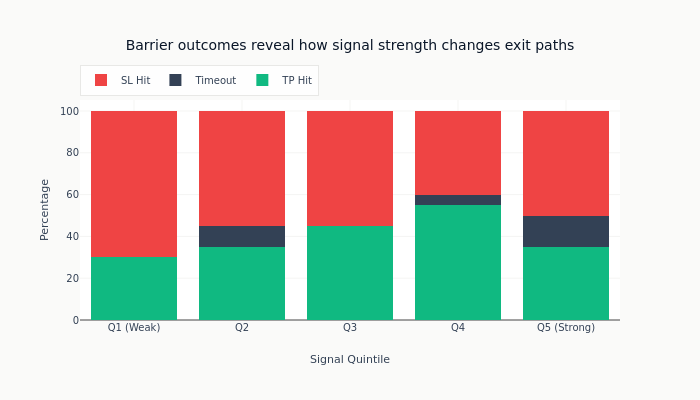

In [63]:
# Visualize barrier outcomes
outcome_summary = merged.groupby(["signal_quintile", "label"]).size().unstack(fill_value=0)
outcome_summary.columns = ["SL Hit", "Timeout", "TP Hit"]
outcome_pct = outcome_summary.div(outcome_summary.sum(axis=1), axis=0) * 100

fig = go.Figure()

for col, color in zip(
    ["TP Hit", "Timeout", "SL Hit"],
    [COLORS["positive"], COLORS["neutral"], COLORS["negative"]],
    strict=True,
):
    fig.add_trace(
        go.Bar(
            x=outcome_pct.index.astype(str),
            y=outcome_pct[col],
            name=col,
            marker_color=color,
        )
    )

fig.update_layout(
    title="Barrier outcomes reveal how signal strength changes exit paths",
    xaxis_title="Signal Quintile",
    yaxis_title="Percentage",
    barmode="stack",
    height=400,
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
)
fig.show()

**Interpreting BarrierAnalysis Results**:

| Pattern | Interpretation | Action |
|---------|----------------|--------|
| Q5 has higher TP rate | Strong signals work | Scale up on strong signals |
| Q1 has higher SL rate | Weak signals fail | Avoid/reduce weak signals |
| No quintile difference | Signal doesn't predict outcomes | Improve signal or features |
| High timeout rate | Exits too tight or signal too slow | Adjust barrier parameters |


## 8. Key Takeaways

| Strategy | Strength | Weakness |
|----------|----------|----------|
| **Fixed SL/TP** | Simple, predictable | Ignores volatility |
| **Trailing Stop** | Locks in profits | May exit too early in trends |
| **ATR-Based** | Adapts to volatility | Requires calibration |
| **ML-Based** | Can flag regime changes | Requires purged temporal validation |
| **Hybrid** | Combines signals | Inherits the most aggressive rule |

1. **Tighter stops reduce per-trade loss but increase whipsaws;** wider
   stops admit noise but cap fewer losers. Match the stop to the trading
   timeframe and the asset's volatility rather than a generic preference.
2. **ATR-based stops adapt to volatility without re-tuning** a fixed
   percentage; this is the cheapest robustness upgrade over fixed stops.
3. **ML exits require a stricter timing contract than fixed rules.** The
   five-day forward label requires a five-row purge at the train/test
   boundary. Each close-based probability is keyed by timestamp and delayed
   to the next session's open; a positional or same-close mapping would
   silently evaluate exits on the wrong date. Treat the model as an overlay
   on explicit stops unless its chronological test results justify more.

**Next**: [`03_position_sizing_mae_mfe`](03_position_sizing_mae_mfe.ipynb)
connects these exit policies to position sizing and excursion-based
calibration; `BarrierAnalysis` validates that a signal predicts barrier
outcomes, not just returns.